In [2]:
pip install matplotlib torchvision

Note: you may need to restart the kernel to use updated packages.


Classes: ['Parasitized', 'Uninfected']
Class mapping: {'Parasitized': 0, 'Uninfected': 1}
Total Images: 27558
Parasitized: 13779
Uninfected: 13779


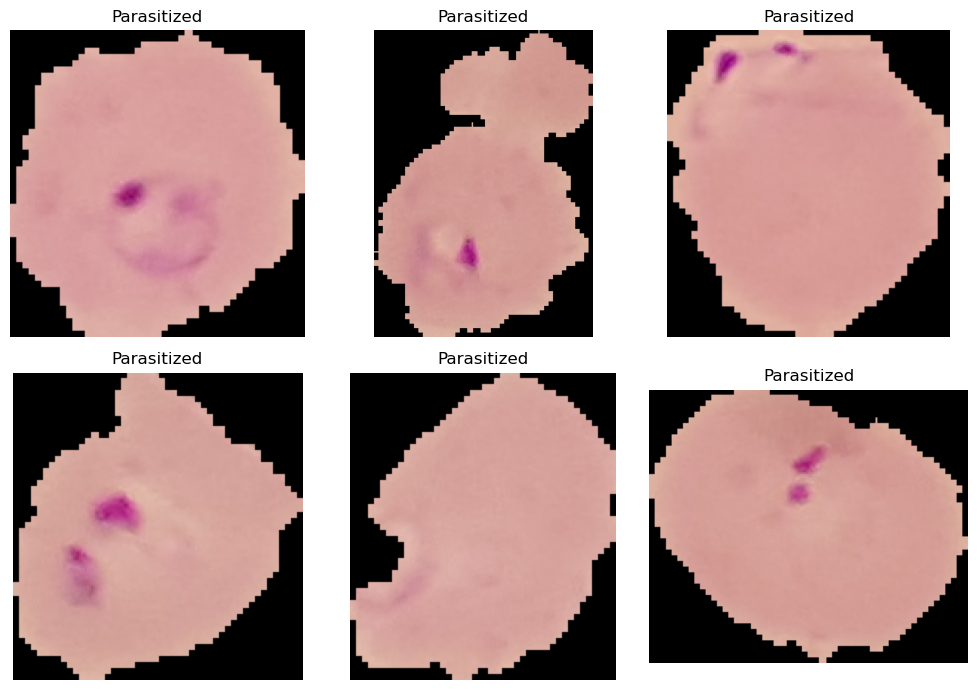

In [6]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from collections import Counter

# Dataset path
data_dir = "/Users/hardikchandna/Documents/AI_Project2_CNN/data/cell_images"


# Basic transform (only convert to tensor for now)
transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform)

print("Classes:", dataset.classes)
print("Class mapping:", dataset.class_to_idx)
print("Total Images:", len(dataset))

# Count labels
labels = [label for _, label in dataset]
counts = Counter(labels)

for idx, count in counts.items():
    print(f"{dataset.classes[idx]}: {count}")

# Show sample images
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for i, ax in enumerate(axes.flat):
    img, label = dataset[i]
    img = img.permute(1, 2, 0)   # CHW -> HWC
    ax.imshow(img)
    ax.set_title(dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
import os
print(os.getcwd())

/Users/hardikchandna/Documents/AI_Project2_CNN/notebooks


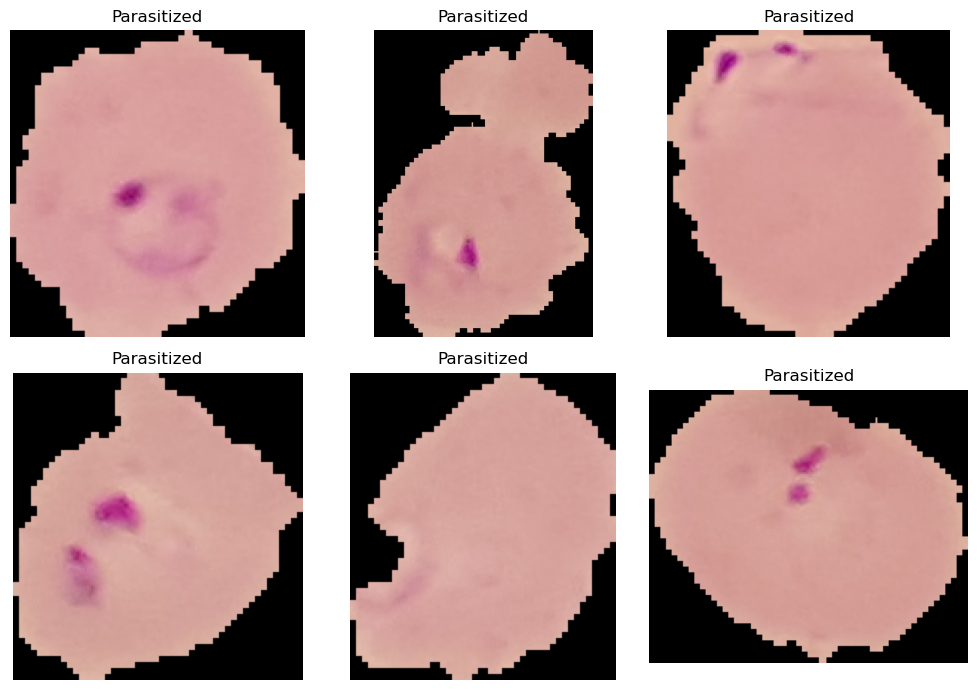

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(10,7))

for i, ax in enumerate(axes.flat):
    img, label = dataset[i]
    img = img.permute(1,2,0)   # tensor to display format
    ax.imshow(img)
    ax.set_title(dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

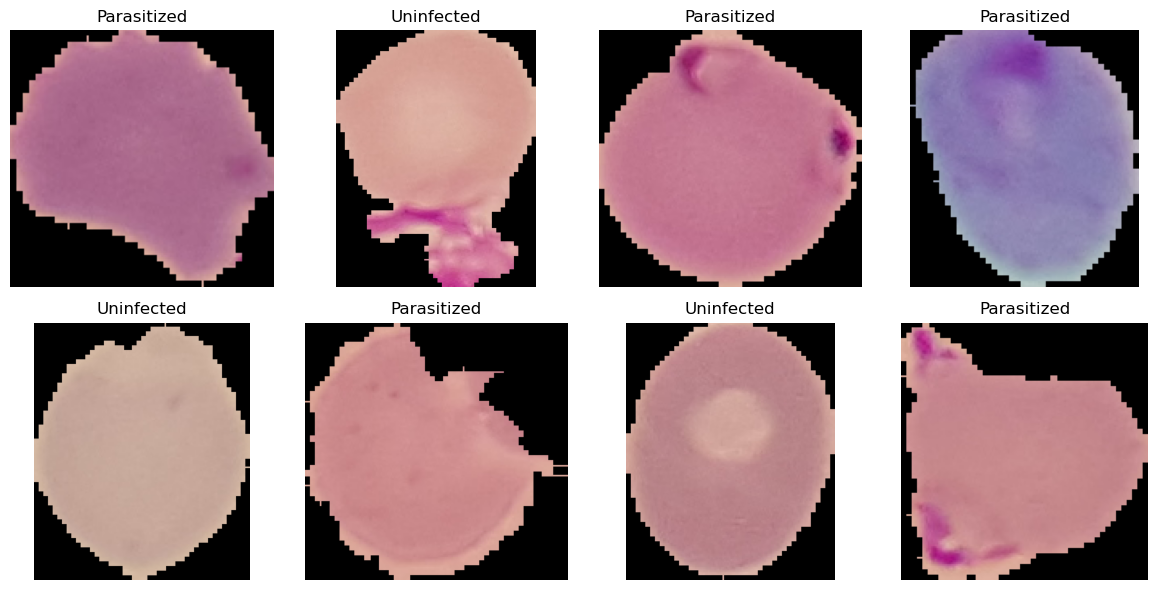

In [8]:
import random
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(12,6))

for ax in axes.flat:
    idx = random.randint(0, len(dataset)-1)
    img, label = dataset[idx]
    img = img.permute(1,2,0)
    
    ax.imshow(img)
    ax.set_title(dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

# ----------------------------
# Path
# ----------------------------
data_dir = "/Users/hardikchandna/Documents/AI_Project2_CNN/data/cell_images"
# ----------------------------
# Base dataset (no transforms yet)
# ----------------------------
base_dataset = datasets.ImageFolder(root=data_dir)

# ----------------------------
# Sizes
# ----------------------------
total_size = len(base_dataset)

train_size = int(0.70 * total_size)
val_size   = int(0.15 * total_size)
test_size  = total_size - train_size - val_size

# ----------------------------
# Split reproducibly
# ----------------------------
generator = torch.Generator().manual_seed(42)

train_data, val_data, test_data = random_split(
    base_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_data))

Train: 19290
Val: 4133
Test: 4135


In [11]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset

# ----------------------------
# Transforms
# ----------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Reload full dataset with transforms later
full_train_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
full_test_dataset  = datasets.ImageFolder(root=data_dir, transform=test_transform)

# Use same indices from previous split
train_dataset = Subset(full_train_dataset, train_data.indices)
val_dataset   = Subset(full_test_dataset, val_data.indices)
test_dataset  = Subset(full_test_dataset, test_data.indices)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 603
Val batches: 130
Test batches: 130


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# Load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace final classifier
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model.fc)

Using device: mps
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/hardikchandna/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:18<00:00, 2.50MB/s]

Linear(in_features=512, out_features=2, bias=True)


In [13]:
from tqdm import tqdm

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f}")
    print(f"Val Acc:    {val_acc:.2f}%")

100%|█████████████████████████████████████████████████████████████████████████████████| 603/603 [02:29<00:00,  4.03it/s]


Epoch 1/5
Train Loss: 0.1567
Val Loss:   0.1428
Val Acc:    96.32%


100%|█████████████████████████████████████████████████████████████████████████████████| 603/603 [02:41<00:00,  3.74it/s]


Epoch 2/5
Train Loss: 0.1330
Val Loss:   0.1178
Val Acc:    96.20%


100%|█████████████████████████████████████████████████████████████████████████████████| 603/603 [02:52<00:00,  3.50it/s]


Epoch 3/5
Train Loss: 0.1221
Val Loss:   0.1136
Val Acc:    96.37%


100%|█████████████████████████████████████████████████████████████████████████████████| 603/603 [03:00<00:00,  3.35it/s]


Epoch 4/5
Train Loss: 0.1179
Val Loss:   0.1037
Val Acc:    96.71%


100%|█████████████████████████████████████████████████████████████████████████████████| 603/603 [02:52<00:00,  3.50it/s]


Epoch 5/5
Train Loss: 0.1119
Val Loss:   0.1016
Val Acc:    96.78%


In [14]:
best_val_acc = 96.78   # from previous run

extra_epochs = 5

for epoch in range(extra_epochs):
    current_epoch = 6 + epoch

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    print(f"Epoch {current_epoch}/10")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f}")
    print(f"Val Acc:    {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet18_malaria.pth")
        print("Best model saved!")

Epoch 6/10
Train Loss: 0.1085
Val Loss:   0.1555
Val Acc:    95.21%
Epoch 7/10
Train Loss: 0.1061
Val Loss:   0.0936
Val Acc:    97.02%
Best model saved!
Epoch 8/10
Train Loss: 0.1028
Val Loss:   0.0892
Val Acc:    97.14%
Best model saved!
Epoch 9/10
Train Loss: 0.0967
Val Loss:   0.1009
Val Acc:    96.64%
Epoch 10/10
Train Loss: 0.0930
Val Loss:   0.0955
Val Acc:    96.78%


In [16]:
# Load best saved weights
model.load_state_dict(torch.load("best_resnet18_malaria.pth"))
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 96.66%


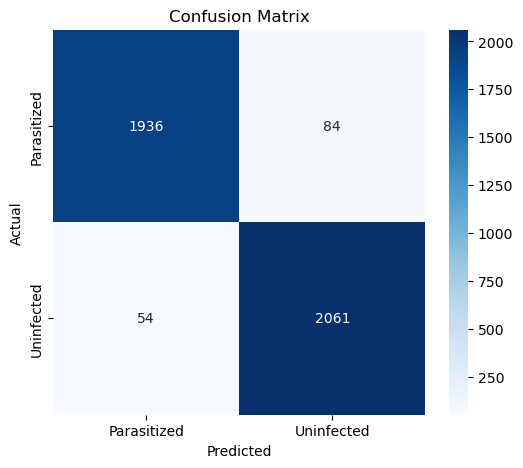

              precision    recall  f1-score   support

 Parasitized       0.97      0.96      0.97      2020
  Uninfected       0.96      0.97      0.97      2115

    accuracy                           0.97      4135
   macro avg       0.97      0.97      0.97      4135
weighted avg       0.97      0.97      0.97      4135



In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(all_labels, all_preds, target_names=dataset.classes))

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_probs = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:,0]   # probability of Parasitized

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

# safer threshold
threshold = 0.35

preds = [0 if p > threshold else 1 for p in all_probs]

cm = confusion_matrix(all_labels, preds)
print(cm)

print(classification_report(
    all_labels,
    preds,
    target_names=["Parasitized", "Uninfected"]
))

[[1963   57]
 [  75 2040]]
              precision    recall  f1-score   support

 Parasitized       0.96      0.97      0.97      2020
  Uninfected       0.97      0.96      0.97      2115

    accuracy                           0.97      4135
   macro avg       0.97      0.97      0.97      4135
weighted avg       0.97      0.97      0.97      4135



In [20]:
pip install grad-cam

Note: you may need to restart the kernel to use updated packages.


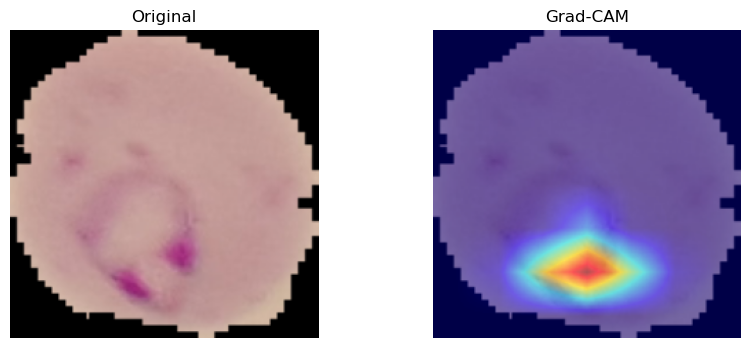

True Label: Parasitized
Predicted: Parasitized


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# choose last conv layer of ResNet18
target_layer = model.layer4[-1]

cam = GradCAM(model=model, target_layers=[target_layer])

# pick one test image
img_tensor, label = test_dataset[0]

input_tensor = img_tensor.unsqueeze(0).to(device)

# target class = predicted class
outputs = model(input_tensor)
pred_class = outputs.argmax(dim=1).item()

targets = [ClassifierOutputTarget(pred_class)]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

# convert tensor image for display 
img_np = img_tensor.permute(1,2,0).cpu().numpy()

# unnormalize for display
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

img_np = std * img_np + mean
img_np = np.clip(img_np, 0, 1)

visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

print("True Label:", dataset.classes[label])
print("Predicted:", dataset.classes[pred_class])

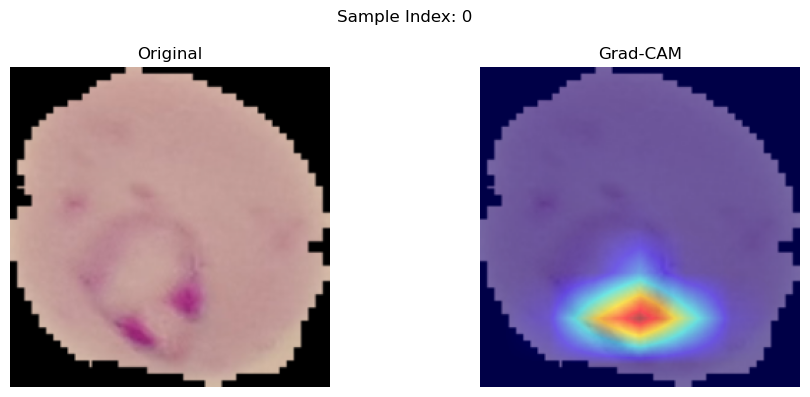

True Label : Parasitized
Predicted  : Parasitized
--------------------------------------------------


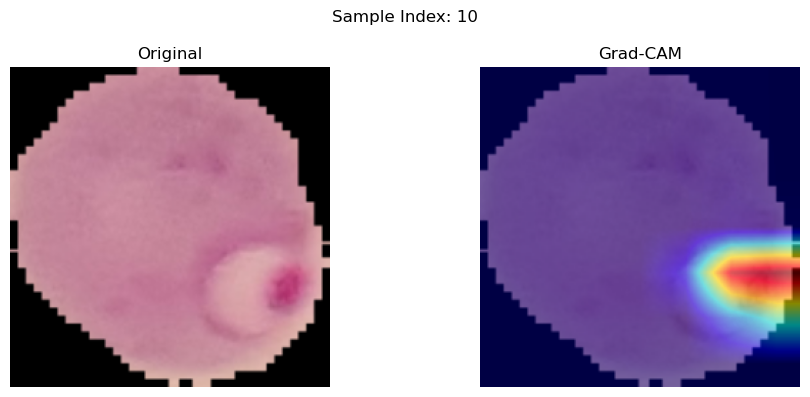

True Label : Parasitized
Predicted  : Parasitized
--------------------------------------------------


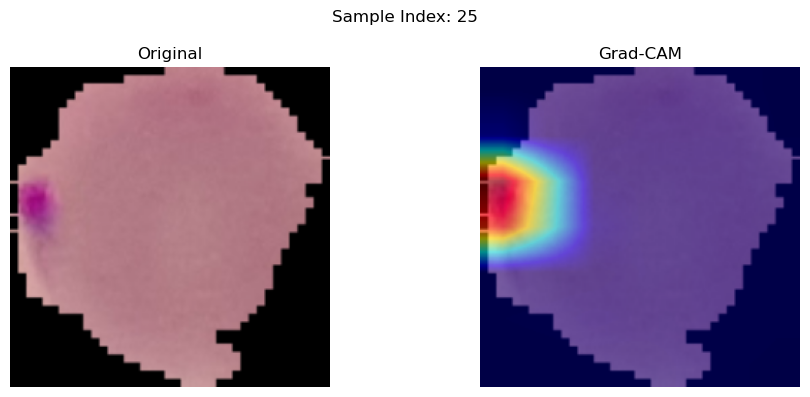

True Label : Parasitized
Predicted  : Parasitized
--------------------------------------------------


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# --------------------------------------------------
# Assumes these already exist from your notebook:
# model
# device
# test_dataset
# dataset.classes
# --------------------------------------------------

# Use last conv block of ResNet18
target_layer = model.layer4[-1]

# Create Grad-CAM object
cam = GradCAM(model=model, target_layers=[target_layer])

# --------------------------------------------------
# Choose multiple test examples
# Change these indices however you like
# --------------------------------------------------
sample_indices = [0, 10, 25]

for idx in sample_indices:

    # Get image + true label
    img_tensor, label = test_dataset[idx]

    # Add batch dimension
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # Predict class
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        pred_class = outputs.argmax(dim=1).item()

    # Target predicted class for Grad-CAM
    targets = [ClassifierOutputTarget(pred_class)]

    # Generate CAM
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    # Convert tensor image for display
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()

    # Unnormalize image
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    # Overlay heatmap
    visualization = show_cam_on_image(
        img_np,
        grayscale_cam,
        use_rgb=True
    )

    # ----------------------------------------------
    # Show results
    # ----------------------------------------------
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(visualization)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.suptitle(f"Sample Index: {idx}")
    plt.tight_layout()
    plt.show()

    print("True Label :", dataset.classes[label])
    print("Predicted  :", dataset.classes[pred_class])
    print("-" * 50)

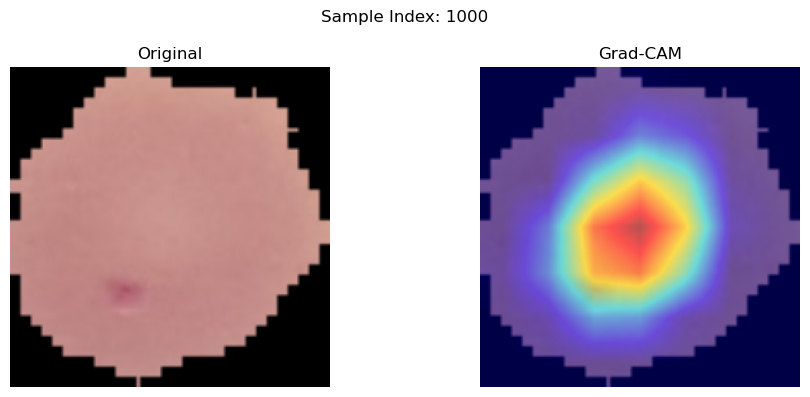

True Label : Uninfected
Predicted  : Uninfected
--------------------------------------------------


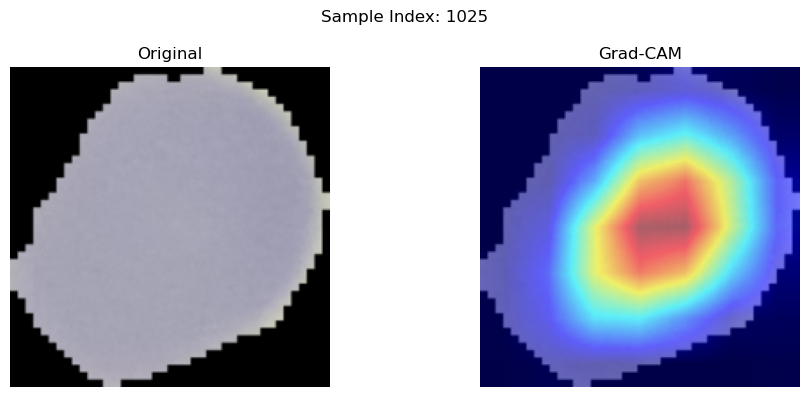

True Label : Uninfected
Predicted  : Uninfected
--------------------------------------------------


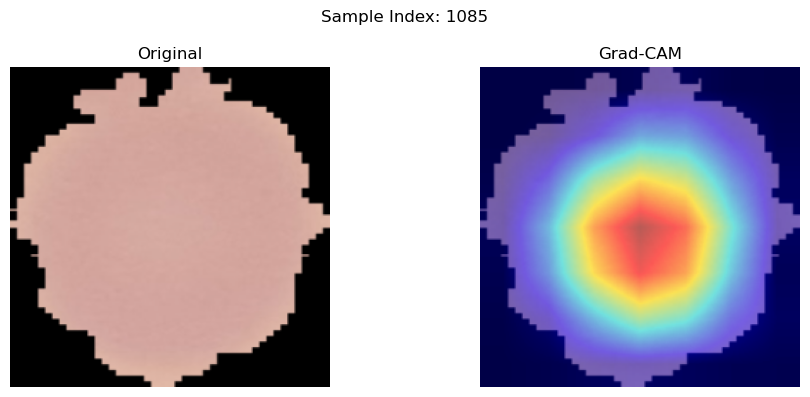

True Label : Uninfected
Predicted  : Uninfected
--------------------------------------------------


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# --------------------------------------------------
# Assumes these already exist from your notebook:
# model
# device
# test_dataset
# dataset.classes
# --------------------------------------------------

# Use last conv block of ResNet18
target_layer = model.layer4[-1]

# Create Grad-CAM object
cam = GradCAM(model=model, target_layers=[target_layer])

# --------------------------------------------------
# Choose multiple test examples
# Change these indices however you like
# --------------------------------------------------
sample_indices = [1000, 1025, 1085]

for idx in sample_indices:

    # Get image + true label
    img_tensor, label = test_dataset[idx]

    # Add batch dimension
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # Predict class
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        pred_class = outputs.argmax(dim=1).item()

    # Target predicted class for Grad-CAM
    targets = [ClassifierOutputTarget(pred_class)]

    # Generate CAM
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    # Convert tensor image for display
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()

    # Unnormalize image
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    # Overlay heatmap
    visualization = show_cam_on_image(
        img_np,
        grayscale_cam,
        use_rgb=True
    )

    # ----------------------------------------------
    # Show results
    # ----------------------------------------------
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(visualization)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.suptitle(f"Sample Index: {idx}")
    plt.tight_layout()
    plt.show()

    print("True Label :", dataset.classes[label])
    print("Predicted  :", dataset.classes[pred_class])
    print("-" * 50)